   # Working with Order Book Data: NASDAQ ITCH

   The primary source of market data is the order book, which is continuously updated in real-time throughout the day to reflect all trading activity. Exchanges typically offer this data as a real-time service and may provide some historical data for free.

   The trading activity is reflected in numerous messages about trade orders sent by market participants. These messages typically conform to the electronic Financial Information eXchange (FIX) communications protocol for real-time exchange of securities transactions and market data or a native exchange protocol.

   ## Imports

In [1]:
from pathlib import Path
from collections import Counter
from datetime import timedelta
from datetime import datetime
from time import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
sns.set_style('whitegrid')

In [3]:
def format_time(t):
    """Return a formatted time string 'HH:MM:SS
    based on a numeric time() value"""
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:0>2.0f}:{m:0>2.0f}:{s:0>2.0f}'

   ### Set Data paths

   We will store the download in a `data` subdirectory and convert the result to `hdf` format (discussed in the last section of chapter 2).

In [4]:
data_path = Path('data') # set to e.g. external harddrive
SOURCE_FILE = '10302019.NASDAQ_ITCH50.gz'
itch_store = str(data_path / (Path(SOURCE_FILE).stem + '.h5'))
date = '10302019'
# stock = 'AAPL'
# stock = 'AMZN'
# stock = 'FB'
stock = 'TSLA'
order_book_store = data_path / f"{Path(SOURCE_FILE).stem}_{stock}_order_book.h5"

   ## Build Order Book

In [5]:
order_dict = {-1: 'sell', 1: 'buy'}

   The parsed messages allow us to rebuild the order flow for the given day. The 'R' message type contains a listing of all stocks traded during a given day, including information about initial public offerings (IPOs) and trading restrictions.

   Throughout the day, new orders are added, and orders that are executed and canceled are removed from the order book. The proper accounting for messages that reference orders placed on a prior date would require tracking the order book over multiple days, but we are ignoring this aspect here.

   ### Get all messages for given stock

   The `get_messages()` function illustrates how to collect the orders for a single stock that affects trading (refer to the ITCH specification for details about each message):

In [6]:
def get_messages(date, stock=stock):
    """Collect trading messages for given stock.

    Builds a *live* order registry so that chained U (Replace) messages
    and subsequent E/C/X/D messages always reference the correct
    buy_sell_indicator, current shares, and current price.
    """
    with pd.HDFStore(itch_store) as store:
        # Fixed-format HDF5: load full table, filter in memory (fast with 128GB RAM)
        r_data = store['R']
        stock_locate = r_data[r_data.stock == stock].stock_locate.iloc[0]

        data = {}
        # trading message types:
        # A: Add Order                  (has buy_sell_indicator, shares)
        # F: Add Order with MPID        (has buy_sell_indicator, shares)
        # E: Order Executed             (uses executed_shares)
        # C: Executed with Price        (uses executed_shares, check printable)
        # X: Order Cancel               (uses cancelled_shares)
        # D: Order Delete               (uses full order shares)
        # U: Replace Order              (has new shares, requires old order lookup)
        # P: Trade Non-Cross            (has buy_sell_indicator, shares)
        # Q: Cross Trade                (has shares)
        messages = ['A', 'F', 'E', 'C', 'X', 'D', 'U', 'P', 'Q']
        for m in messages:
            df = store[m]
            data[m] = df[df.stock_locate == stock_locate].drop('stock_locate', axis=1).assign(type=m)

    # -----------------------------------------------------------------
    # Build a LIVE order registry: order_ref -> (buy_sell_indicator, shares, price)
    # This handles chained U messages correctly.
    # -----------------------------------------------------------------
    order_cols = ['order_reference_number', 'buy_sell_indicator', 'shares', 'price']
    initial_orders = pd.concat([data['A'], data['F']], sort=False, ignore_index=True).loc[:, order_cols]

    # Start with A/F orders
    # A: Add Order                  (has buy_sell_indicator, shares)
    # F: Add Order with MPID        (has buy_sell_indicator, shares)
    order_registry = {}
    for row in initial_orders.itertuples(index=False):
        order_registry[row.order_reference_number] = (
            row.buy_sell_indicator, row.shares, row.price
        )

    # Process U messages in timestamp order to handle chained replacements
    # U: Replace Order              (has new shares, requires old order lookup)
    u_sorted = data['U'].sort_values('timestamp')
    for row in u_sorted.itertuples(index=False):
        orig_ref = row.original_order_reference_number
        new_ref = row.new_order_reference_number
        if orig_ref in order_registry:
            old_buysell, old_shares, old_price = order_registry[orig_ref]
            # Register the NEW order with the new price/shares but same side
            order_registry[new_ref] = (old_buysell, row.shares, row.price)
            # Keep old entry so we can look up the replaced values
        # If orig_ref not found, this is an order from a prior day; skip

    # -----------------------------------------------------------------
    # Now enrich each message type using the registry
    # -----------------------------------------------------------------
    def lookup_order(ref):
        """Return (buy_sell_indicator, shares, price) or (NaN, NaN, NaN)."""
        if ref in order_registry:
            return order_registry[ref]
        return (np.nan, np.nan, np.nan)

    # E, C, X, D: merge with registry on order_reference_number
    # E: Order Executed             (uses executed_shares)
    # C: Executed with Price        (uses executed_shares, check printable)
    # X: Order Cancel               (uses cancelled_shares)
    # D: Order Delete               (uses full order shares)
    for m in ['E', 'C', 'X', 'D']:
        refs = data[m]['order_reference_number']
        looked_up = refs.apply(lookup_order)
        data[m] = data[m].assign(
            buy_sell_indicator=[x[0] for x in looked_up],
            shares=[x[1] for x in looked_up],
            price=[x[2] for x in looked_up]
        )

    # U messages: need both the NEW order info (already in the message)
    # and the REPLACED (old) order info from the registry
    u_data = data['U'].copy()
    old_refs = u_data['original_order_reference_number']
    looked_up_old = old_refs.apply(lookup_order)
    u_data = u_data.assign(
        buy_sell_indicator=[x[0] for x in looked_up_old],
        shares_replaced=[x[1] for x in looked_up_old],
        price_replaced=[x[2] for x in looked_up_old]
    )
    data['U'] = u_data

    # X: use cancelled_shares as shares
    # X: Order Cancel               (uses cancelled_shares)
    data['X']['shares'] = data['X']['cancelled_shares']
    data['X'] = data['X'].dropna(subset=['price'])

    data['Q'].rename(columns={'cross_price': 'price'}, inplace=True)

    data = pd.concat([data[m] for m in messages], ignore_index=True, sort=False)
    data['date'] = pd.to_datetime(date, format='%m%d%Y')
    data.timestamp = data['date'].add(data.timestamp)
    # NOTE: Do NOT filter printable != 0 here.
    # C messages with printable=0 (non-printable cross executions) still
    # remove shares from the order book. Filtering them here causes phantom
    # orders to accumulate at stale price levels (Bug 5).
    # The printable filter is applied only in get_trades() for trade records.

    drop_cols = ['tracking_number', 'order_reference_number', 'original_order_reference_number',
                 'cross_type', 'new_order_reference_number', 'attribution', 'match_number',
                 'date', 'cancelled_shares']
    return data.drop(drop_cols, axis=1, errors='ignore').sort_values('timestamp').reset_index(drop=True)

In [7]:
import os
from pathlib import Path

book_exists = False
store_path = Path(order_book_store)
if store_path.exists():
    with pd.HDFStore(store_path, mode='r') as store:
        if f'/{stock}/buy' in store.keys() and f'/{stock}/sell' in store.keys():
            book_exists = True

if book_exists:
    print(f"Order book for {stock} already exists in {order_book_store}. cells will skip rebuild.")

In [8]:
if not book_exists:
    pass
    print("Loading and filtering messages...")
    SCRIPT_START = time()
    messages = get_messages(date=date)
    messages.info(show_counts=True)

Loading and filtering messages...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485131 entries, 0 to 485130
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   timestamp           485131 non-null  datetime64[ns]
 1   buy_sell_indicator  485129 non-null  float64       
 2   shares              485131 non-null  int64         
 3   price               485131 non-null  int64         
 4   type                485131 non-null  object        
 5   executed_shares     20960 non-null   float64       
 6   printable           174 non-null     float64       
 7   execution_price     174 non-null     float64       
 8   shares_replaced     45375 non-null   float64       
 9   price_replaced      45375 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 37.0+ MB


In [9]:
if not book_exists:
    pass
    with pd.HDFStore(order_book_store) as store:
        key = f'{stock}/messages'
        store.put(key, messages)
        print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: data/10302019.NASDAQ_ITCH50_TSLA_order_book.h5
/TSLA/messages            frame        (shape->[485131,10])


   ### Combine Trading Records

   Reconstructing successful trades, that is, orders that are executed as opposed to those that were canceled from trade-related message types, C, E, P, and Q, is relatively straightforward:

   - E: Order Executed             (uses executed_shares)
   - C: Executed with Price        (uses executed_shares, check printable)
   - P: Trade Non-Cross            (has buy_sell_indicator, shares)
   - Q: Cross Trade                (has shares)

In [10]:
if not book_exists:
    pass
    def get_trades(m):
        """Combine C, E, P and Q messages into trading records"""
        trade_dict = {'executed_shares': 'shares', 'execution_price': 'price'}
        cols = ['timestamp', 'executed_shares']
        trades = pd.concat([m.loc[m.type == 'E', cols + ['price']].rename(columns=trade_dict),
                            m.loc[(m.type == 'C') & (m.printable != 0), cols + ['execution_price']].rename(columns=trade_dict),
                            m.loc[m.type == 'P', ['timestamp', 'price', 'shares']],
                            m.loc[m.type == 'Q', ['timestamp', 'price', 'shares']].assign(cross=1),
                            ], sort=False).dropna(subset=['price']).fillna(0)
        return trades.set_index('timestamp').sort_index().astype(int)

In [11]:
if not book_exists:
    pass
    trades = get_trades(messages)
    print(trades.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32745 entries, 2019-10-30 04:00:50.927915744 to 2019-10-30 19:58:00.497369487
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   shares  32745 non-null  int64
 1   price   32745 non-null  int64
 2   cross   32745 non-null  int64
dtypes: int64(3)
memory usage: 1023.3 KB
None


In [12]:
if not book_exists:
    pass
    with pd.HDFStore(order_book_store) as store:
        store.put(f'{stock}/trades', trades)

   ### Create Orders

   The order book keeps track of limit orders, and the various price levels for buy and sell orders constitute the depth of the order book. To reconstruct the order book for a given level of depth requires the following steps:


   The `add_orders()` function accumulates sell orders in ascending, and buy orders in descending order for a given timestamp up to the desired level of depth:

In [13]:
if not book_exists:
    pass
    import bisect

    def add_orders_fast(orders, buysell, nlevels, active_prices):
        """Add orders up to desired depth given by nlevels using pre-sorted price lists.
            sell (buysell=-1) in ascending, buy (buysell=1) in descending order
        """
        new_order = []
        prices = active_prices[buysell]
    
        if buysell == 1:
            # Buy: highest bids first (end of sorted array)
            start_idx = max(0, len(prices) - nlevels)
            for p in reversed(prices[start_idx:]):
                new_order.append((p, orders[p]))
        else:
            # Sell: lowest asks first (start of sorted array)
            end_idx = min(len(prices), nlevels)
            for p in prices[:end_idx]:
                new_order.append((p, orders[p]))
            
        return new_order

In [14]:
if not book_exists:
    pass
    def save_orders(orders, append=False):
        for buysell, book in orders.items():
            if not book:
                continue
            
            timestamps, prices, shares = [], [], []
            for t, data in book.items():
                for p, s in data:
                    timestamps.append(t)
                    prices.append(p)
                    shares.append(s)
                
            df = pd.DataFrame({'price': prices, 'shares': shares, 'timestamp': timestamps})
            key = f'{stock}/{order_dict[buysell]}'
            df.loc[:, ['price', 'shares']] = df.loc[:, ['price', 'shares']].astype(int)
            with pd.HDFStore(order_book_store) as store:
                if append:
                    store.append(key, df.set_index('timestamp'), format='t')
                else:
                    store.put(key, df.set_index('timestamp'))

   We iterate over all ITCH messages and process orders and their replacements as required by the specification (this can take a while):

In [15]:
if not book_exists:
    pass
    order_book = {-1: {}, 1: {}}
    current_orders = {-1: Counter(), 1: Counter()}
    active_prices = {-1: [], 1: []}  # Sorted lists for O(1) access
    message_counter = Counter()
    nlevels = 100

    import os
    import shutil

    # Clean up existing order book data for this stock to prevent duplicate appending
    # We copy all other data to a temporary store, delete the original, and replace it
    # because store.remove() does not reclaim file space in HDF5 and causes file size explosion
    store_path = Path(order_book_store)
    if store_path.exists():
        temp_store_path = store_path.parent / (store_path.stem + "_temp.h5")
    
        with pd.HDFStore(store_path, mode="r") as store:
            keys_to_keep = [k for k in store.keys() if k not in [f"/{stock}/{order_dict[-1]}", f"/{stock}/{order_dict[1]}"]]
        
        if len(keys_to_keep) > 0:
            with pd.HDFStore(store_path, mode="r") as store, \
                 pd.HDFStore(temp_store_path, mode="w", complib="blosc", complevel=9) as new_store:
                for k in keys_to_keep:
                    storer = store.get_storer(k)
                    format_str = "table" if storer.format_type == "table" else "fixed"
                    new_store.put(k, store.get(k), format=format_str)
        
            os.replace(temp_store_path, store_path)
        else:
            # If no keys left, just delete the file entirely
            store_path.unlink()


    start = time()
    for message in messages.itertuples():
        i = message[0]
        if i % 1e5 == 0 and i > 0:
            print(f'{i:,.0f}\t\t{format_time(time() - start)}')
            save_orders(order_book, append=True)
            order_book = {-1: {}, 1: {}}
            start = time()
        if np.isnan(message.buy_sell_indicator):
            continue
        message_counter.update(message.type)

        buysell = message.buy_sell_indicator
        price, shares = None, None

        if message.type in ['A', 'F', 'U']:
            # For U messages, only add the new order if the old order was found
            # (i.e., shares_replaced is not NaN). Otherwise we'd add phantom shares
            # without a corresponding removal of the old order.
            if message.type == 'U' and np.isnan(message.shares_replaced):
                continue
            price = int(message.price)
            shares = int(message.shares)

            if price not in current_orders[buysell] or current_orders[buysell][price] == 0:
                bisect.insort(active_prices[buysell], price)
            current_orders[buysell][price] += shares

            new_order = add_orders_fast(current_orders[buysell], buysell, nlevels, active_prices)
            order_book[buysell][message.timestamp] = new_order

        if message.type in ['E', 'C', 'X', 'D', 'U']:
            if message.type == 'U':
                if not np.isnan(message.shares_replaced):
                    price = int(message.price_replaced)
                    shares = -int(message.shares_replaced)
            elif message.type in ['E', 'C']:
                # Bug fix: use executed_shares, not the total order shares
                if not np.isnan(message.price):
                    price = int(message.price)
                    shares = -int(message.executed_shares)
            else:
                # X uses cancelled_shares (set as 'shares' earlier), D uses full order shares
                if not np.isnan(message.price) and not np.isnan(message.shares):
                    price = int(message.price)
                    shares = -int(message.shares)

            if price is not None:
                if price not in current_orders[buysell] or current_orders[buysell][price] == 0:
                    bisect.insort(active_prices[buysell], price)
                current_orders[buysell][price] += shares
            
                if current_orders[buysell][price] <= 0:
                    current_orders[buysell].pop(price, None)
                    # Binary search for removal is fast enough for small N, or we could use a custom remove
                    idx = bisect.bisect_left(active_prices[buysell], price)
                    if idx < len(active_prices[buysell]) and active_prices[buysell][idx] == price:
                        active_prices[buysell].pop(idx)
                    
                new_order = add_orders_fast(current_orders[buysell], buysell, nlevels, active_prices)
                order_book[buysell][message.timestamp] = new_order

    # Save trailing data that didn't hit the 100k boundary
    if order_book[-1] or order_book[1]:
        print(f'Saving final batch...')
        save_orders(order_book, append=True)

    print(f'\nTotal rebuild time: {format_time(time() - SCRIPT_START)}')

100,000		00:00:01
200,000		00:00:02
300,000		00:00:01
400,000		00:00:01
Saving final batch...

Total rebuild time: 00:00:56


In [16]:
if not book_exists:
    pass
    message_counter = pd.Series(message_counter)
    print(message_counter)

A    207247
D    196389
E     20786
P     11799
X       186
F      3173
U     45375
C       174
dtype: int64


In [17]:
if not book_exists:
    pass
    with pd.HDFStore(order_book_store) as store:
        print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: data/10302019.NASDAQ_ITCH50_TSLA_order_book.h5
/TSLA/buy                 frame_table  (typ->appendable,nrows->22634799,ncols->2,indexers->[index],dc->[])
/TSLA/messages            frame        (shape->[485131,10])                                               
/TSLA/sell                frame_table  (typ->appendable,nrows->22283918,ncols->2,indexers->[index],dc->[])
/TSLA/trades              frame        (shape->[32745,3])                                                 


   ## Order Book Depth

In [18]:
with pd.HDFStore(order_book_store) as store:
    buy = store[f'{stock}/buy'].reset_index().drop_duplicates()
    sell = store[f'{stock}/sell'].reset_index().drop_duplicates()

   ### Price to Decimals

In [19]:
buy.price = buy.price.mul(1e-4)
sell.price = sell.price.mul(1e-4)

   ### Remove outliers

In [20]:
percentiles = [.01, .02, .1, .25, .75, .9, .98, .99]
pd.concat([buy.price.describe(percentiles=percentiles).to_frame('buy'),
           sell.price.describe(percentiles=percentiles).to_frame('sell')], axis=1).apply(lambda x: x.map('{:,.2f}'.format))

,buy,sell
count,"22,634,799.00","22,283,918.00"
mean,311.56,316.23
std,3.62,45.90
min,150.00,310.01
1%,303.51,311.33
2%,305.88,311.68
10%,309.53,312.80
25%,310.47,313.93
50%,311.50,315.41
75%,313.02,316.95


In [21]:
buy = buy[buy.price > buy.price.quantile(.01)]
sell = sell[sell.price < sell.price.quantile(.99)]

   ### Buy-Sell Order Distribution

   The number of orders at different price levels, highlighted in the following screenshot using different intensities for buy and sell orders, visualizes the depth of liquidity at any given point in time.

   The distribution of limit order prices was weighted toward buy orders at higher prices.

In [22]:
market_open='0930'
market_close = '1600'

Sell orders at ~$1760.24:
  Count: 0
  Unique shares values: []
  Time range: NaT to NaT


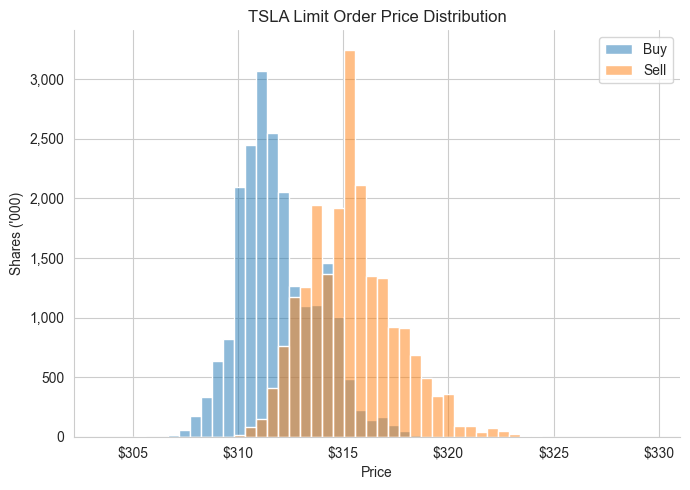

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
fig, ax = plt.subplots(figsize=(7,5))
# Use all data within market hours (outliers were removed in previous steps)
buy_filtered = (buy.set_index('timestamp')
                .between_time(market_open, market_close))

sell_filtered = (sell.set_index('timestamp')
                 .between_time(market_open, market_close))

price_min = min(buy.price.min(), sell.price.min())
price_max = max(buy.price.max(), sell.price.max())
bins = np.linspace(price_min, price_max, 51)

# Modern replacement for the two distplot calls
sns.histplot(data=buy_filtered, x='price', ax=ax, label='Buy',
             alpha=0.5, linewidth=1, bins=bins)   # same look as old distplot

sns.histplot(data=sell_filtered, x='price', ax=ax, label='Sell',
             alpha=0.5, linewidth=1, bins=bins)

ax.legend(fontsize=10)
ax.set_title(f'{stock} Limit Order Price Distribution')

# Diagnostic: check the $1760.24 sell order
suspect_price = 1760.24
sell_at_suspect = sell[abs(sell.price - suspect_price) < 0.01]
print(f"Sell orders at ~${suspect_price}:")
print(f"  Count: {len(sell_at_suspect)}")
print(f"  Unique shares values: {sell_at_suspect.shares.unique()}")
print(f"  Time range: {sell_at_suspect.timestamp.min()} to {sell_at_suspect.timestamp.max()}")


# Clean formatting (no more set_ticklabels warning!)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y/1000):,}'))

ax.set_xlabel('Price')
ax.set_ylabel("Shares ('000)")

sns.despine()
fig.tight_layout()
plt.show()

   ### Order Book Depth

In [24]:
utc_offset = timedelta(hours=4)
depth = 100

In [25]:
def prep_order_book_minute_data(buy, sell, market_open, market_close, utc_offset, depth=100):
    """Calculate the minute-by-minute order book depth for buy and sell limit orders."""
    buy_per_min = (buy
                   .groupby([pd.Grouper(key='timestamp', freq='Min'), 'price'])
                   .shares
                   .sum()
                   .apply(np.log)
                   .to_frame('shares')
                   .reset_index('price')
                   .between_time(market_open, market_close)
                   .groupby(level='timestamp', as_index=False, group_keys=False)
                   .apply(lambda x: x.nlargest(columns='price', n=depth))
                   .reset_index())
    buy_per_min.timestamp = buy_per_min.timestamp.add(utc_offset).astype(int)

    sell_per_min = (sell
                    .groupby([pd.Grouper(key='timestamp', freq='Min'), 'price'])
                    .shares
                    .sum()
                    .apply(np.log)
                    .to_frame('shares')
                    .reset_index('price')
                    .between_time(market_open, market_close)
                    .groupby(level='timestamp', as_index=False, group_keys=False)
                    .apply(lambda x: x.nsmallest(columns='price', n=depth))
                    .reset_index())
    sell_per_min.timestamp = sell_per_min.timestamp.add(utc_offset).astype(int)
    
    return buy_per_min, sell_per_min

def plot_order_book_profile(buy_per_min, sell_per_min, trades_per_min, target_timestamp):
    """Plot the vertical order book profile for a specific timestamp."""
    import plotly.graph_objects as go
    
    target_buy = buy_per_min[buy_per_min['timestamp'] == target_timestamp]
    target_sell = sell_per_min[sell_per_min['timestamp'] == target_timestamp]
    print("==target buy==")
    print(target_buy)
    print("\n")
    print("==target sell==")
    print(target_sell)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=target_buy['timestamp'],
        y=target_buy['price'],
        mode='markers',
        marker=dict(
            color=target_buy['shares'],
            colorscale='Blues',
            opacity=0.5,
            showscale=False
        ),
        name='Buy'
    ))

    fig.add_trace(go.Scatter(
        x=target_sell['timestamp'],
        y=target_sell['price'],
        mode='markers',
        marker=dict(
            color=target_sell['shares'],
            colorscale='Reds',
            opacity=0.5,
            showscale=False
        ),
        name='Sell'
    ))

    if target_timestamp in trades_per_min.index:
        target_trade = trades_per_min.loc[[target_timestamp]]
        if not target_trade.empty and pd.notna(target_trade['price'].iloc[0]):
            fig.add_trace(go.Scatter(
                x=[target_timestamp]*len(target_trade),
                y=target_trade['price'],
                mode='markers',
                marker=dict(
                    color='black',
                    symbol='star',
                    size=15
                ),
                name='Trade'
            ))

    dt_str = pd.to_datetime(target_timestamp, unit='ns').tz_localize('UTC').tz_convert('America/New_York').strftime('%H:%M')
    
    fig.update_layout(
        title=f'{dt_str}<br>Order Book Profile',
        yaxis_title='Price',
        xaxis=dict(
            showticklabels=False,
            title=''
        ),
        width=300,
        height=600,
        showlegend=True,
        template='plotly_white'
    )

    fig.show()

In [26]:
buy_per_min, sell_per_min = prep_order_book_minute_data(buy, sell, market_open, market_close, utc_offset, depth)
buy_per_min.info()
sell_per_min.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39100 entries, 0 to 39099
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  39100 non-null  int64  
 1   price      39100 non-null  float64
 2   shares     39100 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 916.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39100 entries, 0 to 39099
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  39100 non-null  int64  
 1   price      39100 non-null  float64
 2   shares     39100 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 916.5 KB


In [27]:
def get_timestamp(time_str, date_str=date, offset=utc_offset):
    """Convert a time string like '09:30' into the nanosecond timestamp used in the dataset."""
    dt = pd.to_datetime(f'{date_str} {time_str}', format='%m%d%Y %H:%M')
    # Use .value to get the equivalent UTC-epoch nanoseconds (which is what astype(int) does)
    return (dt + offset).value

In [28]:
with pd.HDFStore(order_book_store) as store:
    trades = store[f'{stock}/trades']
trades.price = trades.price.mul(1e-4)
trades = trades[trades.cross == 0].between_time(market_open, market_close)

trades_per_min = (trades
                  .resample('Min')
                  .agg({'price': 'mean', 'shares': 'sum'}))
trades_per_min.index = trades_per_min.index.to_series().add(utc_offset).astype(int)
trades_per_min.info()

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 1572442200000000000 to 1572465540000000000
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   390 non-null    float64
 1   shares  390 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 9.1 KB


In [29]:
plot_order_book_profile(buy_per_min, sell_per_min, trades_per_min, target_timestamp=get_timestamp('12:38')) 

==target buy==
                 timestamp   price    shares
18800  1572453480000000000  312.96  2.708050
18801  1572453480000000000  312.93  8.699515
18802  1572453480000000000  312.83  7.438384
18803  1572453480000000000  312.82  6.995766
18804  1572453480000000000  312.80  8.885303
...                    ...     ...       ...
18895  1572453480000000000  311.83  5.587249
18896  1572453480000000000  311.82  8.582981
18897  1572453480000000000  311.81  7.889834
18898  1572453480000000000  311.80  5.587249
18899  1572453480000000000  311.79  9.783746

[100 rows x 3 columns]


==target sell==
                 timestamp   price     shares
18800  1572453480000000000  312.75   4.094345
18801  1572453480000000000  312.77   6.824374
18802  1572453480000000000  312.82   4.442651
18803  1572453480000000000  312.83   7.438384
18804  1572453480000000000  312.84   9.305651
...                    ...     ...        ...
18895  1572453480000000000  314.90  12.642390
18896  1572453480000000000  314.95 

   ### Order Book Profile and Volume
   The following plots the evolution of limit orders, prices, and volume throughout the trading day. limit orders are indicated by red and blue dots, executed trade prices by the dark line, and volume by the light blue bars on the secondary axis.

In [30]:
import plotly.graph_objects as go

buy_dt = pd.to_datetime(buy_per_min['timestamp'], unit='ns').dt.tz_localize('UTC').dt.tz_convert('America/New_York')
sell_dt = pd.to_datetime(sell_per_min['timestamp'], unit='ns').dt.tz_localize('UTC').dt.tz_convert('America/New_York')
trades_dt = pd.to_datetime(trades_per_min.index, unit='ns').tz_localize('UTC').tz_convert('America/New_York')

fig = go.Figure()

fig.add_trace(go.Bar(
    x=trades_dt,
    y=trades_per_min['shares'],
    name='Volume',
    marker_color='lightslategray',
    opacity=0.4,
    yaxis='y2'
))

fig.add_trace(go.Scatter(
    x=buy_dt,
    y=buy_per_min['price'],
    mode='markers',
    marker=dict(
        color=buy_per_min['shares'],
        colorscale='Blues',
        opacity=0.3,
        showscale=False
    ),
    name='Buy Limit Orders'
))

fig.add_trace(go.Scatter(
    x=sell_dt,
    y=sell_per_min['price'],
    mode='markers',
    marker=dict(
        color=sell_per_min['shares'],
        colorscale='Reds',
        opacity=0.3,
        showscale=False
    ),
    name='Sell Limit Orders'
))

fig.add_trace(go.Scatter(
    x=trades_dt,
    y=trades_per_min['price'],
    mode='lines',
    line=dict(color='black', width=2),
    name='Executed Trades'
))

title = f'{stock} | {date} | Buy & Sell Limit Order Book & Volume | Depth = {depth}'

fig.update_layout(
    title=title,
    xaxis_title='',
    template='plotly_white',
    height=600,
    hovermode='x unified',
    yaxis=dict(
        title='Price',
        side='left',
        showgrid=True
    ),
    yaxis2=dict(
        title='Volume (Shares)',
        side='right',
        overlaying='y',
        showgrid=False
    ),
    xaxis=dict(
        tickformat='%H:%M'
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

fig.show()